In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import root_mean_squared_error as rmse
import time
import tkinter as tk
from tkinter import messagebox
import math
import matplotlib as mpl
from scipy.spatial import ConvexHull
import os
# our functions
import predict_Beta_I
import choice_start_day
import plot_hyb

import warnings
warnings.filterwarnings(action='ignore')

# to account for updates when files change
%load_ext autoreload
%autoreload 2

## !

In [2]:
def apply_methods(seed_dirs='initial_data/initial_data_ba_10000/',
                  seed_numbers=[], on_incidence=False, 
                  switch_on_incidence=False,
                 idx_s=0, idx_e=11, show_fig_flag=False,
                 is_filename=False, sigma=0.1, gamma=0.08, perc_switch=0.01,
                 suff_m='sw100k', suff='sw100k'):
    
    #df_seeds = pd.read_csv(df_seeds)
    if is_filename:
        col = 'file'
    else:
        col='seed_number'
        
    #seed_numbers = df_seeds[df_seeds.set=='test'][col].values[:n_seeds]

    types_start_day = ['fraq_people']#, 'roll_var', 'roll_var_seq']

    methods = ['last value','expanding mean last value',
               'median beta', 
               #'regression (day)',
               'regression beta', #'arimax',
               'lstm'
              ]

    new_labels = ['last_value', 'expanding_mean_last_value', 

            'median_beta', #'regression_day',
            'regression_beta', #'arimax',
                  'lstm_day_E_previous_I'
                 ]

    for type_start_day in types_start_day:

        for beta_pred,new_label in zip(methods[idx_s:idx_e], 
                                       new_labels[idx_s:idx_e]):

            if 'median' in beta_pred:
                model_path = f'{suff_m}_median_beta.csv'
            elif 'regression beta' in  beta_pred:
                model_path = f'{suff_m}_regression_bt.joblib'
            elif 'lstm' in beta_pred:
                model_path = f'{suff_m}_lstm_4_001_s10'   
            else:
                model_path=''
            print('path: ', model_path)
            
            try:
                all_rmse_I, all_rmse_Inc, all_rmse_Beta, \
                    all_r2, all_r2_Inc, all_peak, \
                    execution_time, start_days = plot_hyb.main_f(I_prediction_method='seir', 
                                        stochastic=False, count_stoch_line=0, 
                                        beta_prediction_method=beta_pred, 
                                        type_start_day=type_start_day, 
                                        seed_numbers=seed_numbers, 
                                        show_fig_flag=show_fig_flag,
                                        seed_dirs=seed_dirs, 
                                        sigma=sigma, gamma=gamma, 
                                        ax=None, model_path=model_path,
                                        perc_switch=perc_switch,
                                        is_filename=is_filename,
                                        on_incidence=on_incidence,
                                        switch_on_incidence=switch_on_incidence)
                
                # creating a dataframe for peaks
                all_peak = pd.DataFrame(all_peak, 
                                columns=['actual_peak_I', 'predicted_peak_I', 
                                        'actual_peak_Inc', 'predicted_peak_inc',
                                        'actual_peak_day', 'predicted_peak_day',
                                        'actual_peak_day_Inc', 'predicted_peak_day_inc'])
                # creating a dataframe for peaks RMSE, predicted time, start day
                rmse_df = pd.DataFrame({
                    'rmse_I': all_rmse_I,
                    'rmse_Inc': all_rmse_Inc,
                    'rmse_Beta': all_rmse_Beta,
                    'r2': all_r2,
                    'r2_Inc': all_r2_Inc,
                    'time_predict': execution_time,
                    f'{type_start_day}': start_days})

                # merging dataframes
                results = pd.concat([rmse_df, all_peak], axis=1)
                folder_name = seed_dirs.split('/')[-2]
                
            except FileNotFoundError:
                pass
                
            if not show_fig_flag:
                path = f'results/{folder_name}/{type_start_day}/'
                if not os.path.exists(path):
                    os.makedirs(path)
                results.to_csv(f'{path}/{new_label}_results_{suff}.csv', 
                           index=False)
                

In [3]:
sw = pd.read_csv('ba_test_files.csv').values

In [4]:
sw.shape

(24000, 1)

In [7]:
%%time
# for lstm CPU times: total: 3h 41min 11s
# Wall time: 3h 1min 54s
#apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              switch_on_incidence=False,
              idx_s=4, idx_e=5, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='ba100k', suff='ba100k_sI')

path:  ba100k_lstm_4_001_s10
lstm
CPU times: total: 3h 41min 11s
Wall time: 3h 1min 54s


path:  ba100k_lstm_4_001_s10
lstm


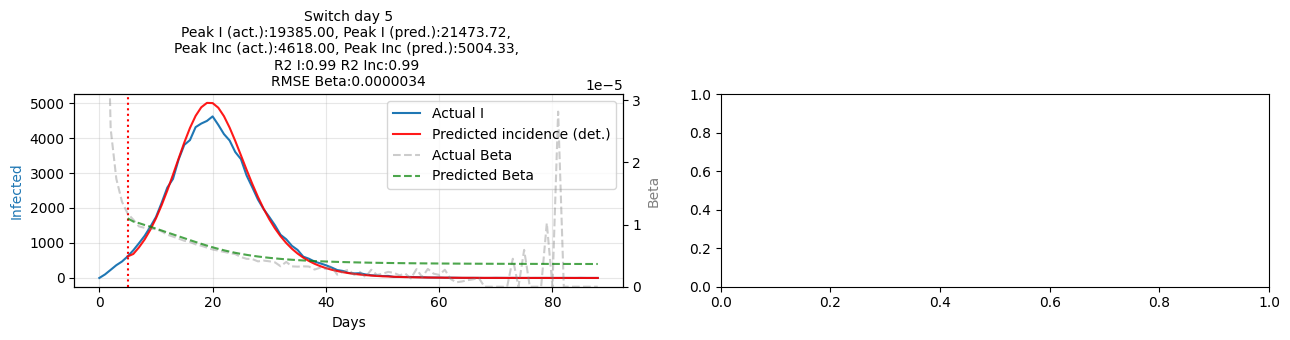

         3298793 function calls (3152649 primitive calls) in 5.139 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     1491    2.181    0.001    2.185    0.001 {built-in method tensorflow.python._pywrap_tfe.TFE_Py_FastPathExecute}
   115/90    0.357    0.003    4.659    0.052 traceback_utils.py:110(error_handler)
       88    0.124    0.001    0.124    0.001 {built-in method tensorflow.python._pywrap_tfe.TFE_Py_Execute}
     2504    0.055    0.000    0.055    0.000 {built-in method tensorflow.python.util._tf_stack.extract_stack}
135240/43176    0.052    0.000    0.090    0.000 options.py:706(__getattribute__)
    60060    0.038    0.000    0.080    0.000 options.py:99(get_fn)
277638/277601    0.037    0.000    0.136    0.000 {built-in method builtins.isinstance}
139383/139293    0.031    0.000    0.118    0.000 {built-in method builtins.getattr}
     2504    0.029    0.000    0.171    0.000 ops.py:999(_create_c_op)
     40

In [9]:
%%prun
k = 2022
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[k:k+1], on_incidence=True,
              switch_on_incidence=False,
              idx_s=4, idx_e=5, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='ba100k', suff='ba100k_sI')

path:  ba100k_regression_bt.joblib
regression beta


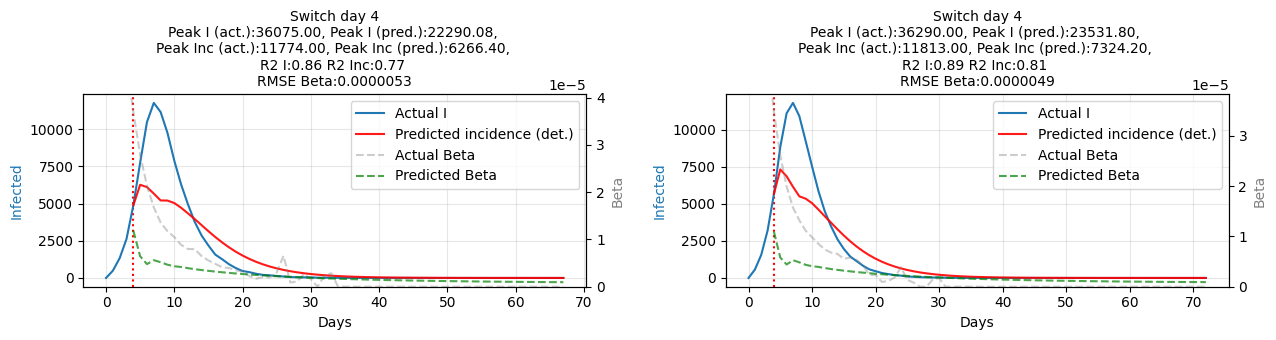

path:  ba100k_lstm_4_001_s10
lstm


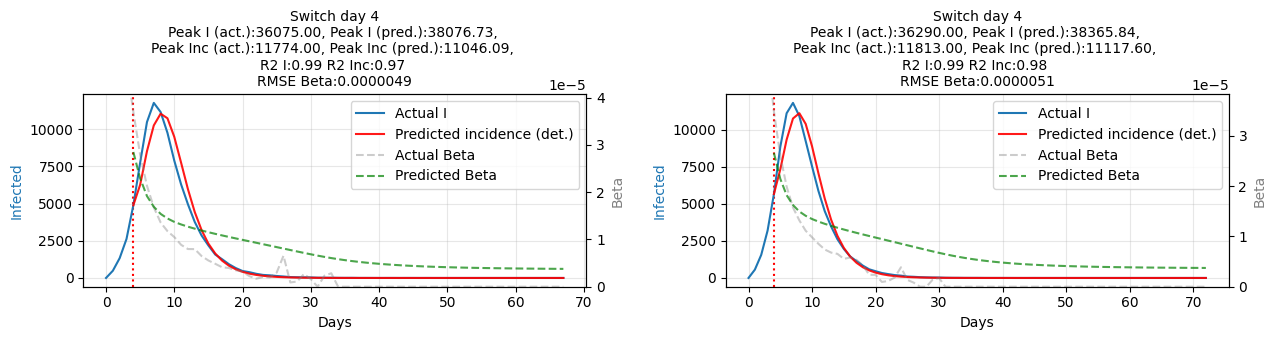

CPU times: total: 8.44 s
Wall time: 7.16 s


In [11]:
%%time
k = 2380
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[-2:], on_incidence=True,
              switch_on_incidence=False,
              idx_s=3, idx_e=5, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='ba100k', suff='ba100k_10')

path:  ba100k_regression_bt.joblib
regression beta


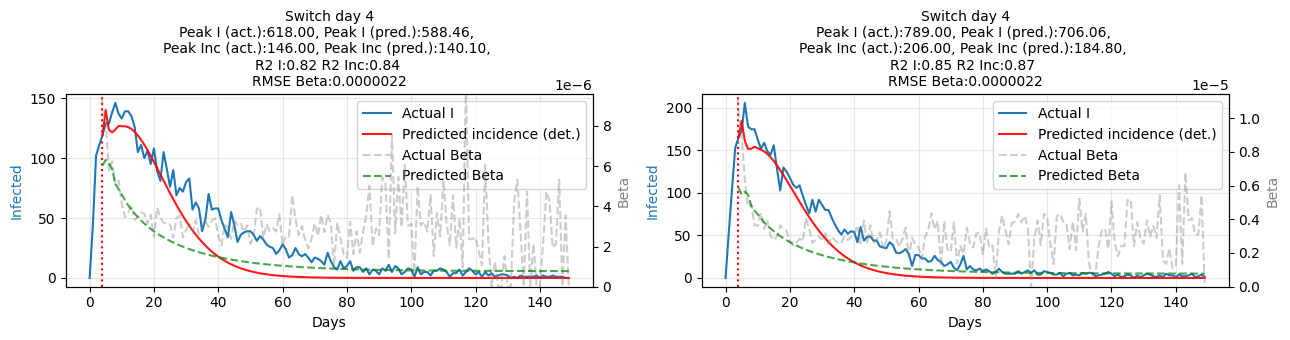

path:  ba100k_lstm_4_001_s10
lstm


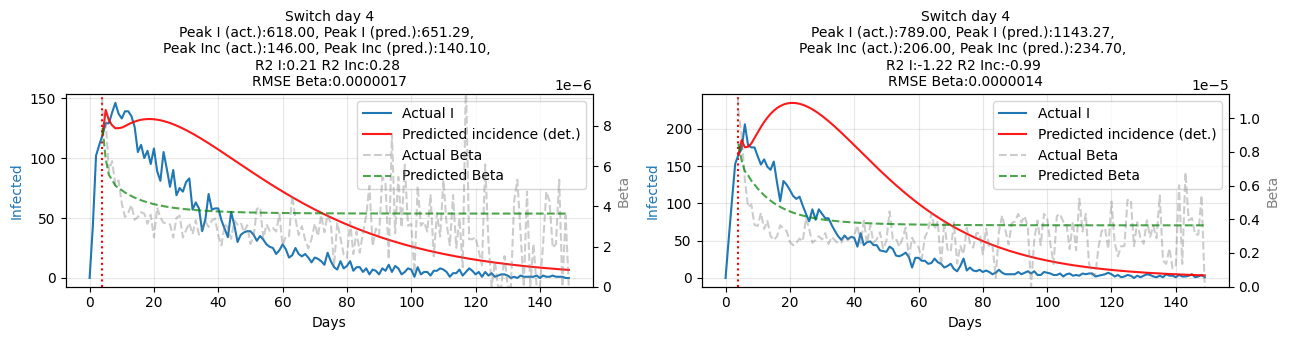

CPU times: total: 17.3 s
Wall time: 14.1 s


In [12]:
%%time
k = 2380
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[k:k+2], on_incidence=True,
              switch_on_incidence=False,
              idx_s=3, idx_e=5, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='ba100k', suff='ba100k_10')

In [15]:
import joblib

In [90]:
seed_df

,S,E,I,R,Beta
0,51991,0,10,47999,0.000617
1,51670,278,45,48007,0.000078
2,51489,357,134,48020,0.000026
3,51308,427,211,48054,0.000015
4,51149,467,276,48108,0.000009
...,...,...,...,...,...
145,46934,2,10,53054,0.000002
146,46933,2,8,53057,0.000005
147,46931,3,8,53058,-0.000000
148,46931,3,6,53060,0.000004


In [91]:
seed_dirs="../new_ba_100000/"
seed_df = pd.read_csv(seed_dirs+sw[k][0])
temp = seed_df[['E','S']].shift([0,1])
# Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
seed_df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                    (temp['S_0'] - temp['S_1'])
seed_df = seed_df[(seed_df['E'] > 0)|(seed_df['I'] > 0)
                         ].fillna(0)
seed_df.replace([np.inf, -np.inf], 0, inplace=True)
    
scaler = joblib.load(f'ba100k_lstm_4_001_s10.pkl')
model = predict_Beta_I.load_model(f'ba100k_lstm_4_001_s10.keras')
window_size=4
predicted_days = [4,5]

In [92]:
seed_df[['Beta']].shift(np.arange(window_size)
                            ).iloc[4]

Beta_0    0.000009
Beta_1    0.000015
Beta_2    0.000026
Beta_3    0.000078
Name: 4, dtype: float64

In [93]:
inp = seed_df[['Beta']].shift(np.arange(window_size)
                            ).iloc[predicted_days[0]
                                  ].values
#[t, t-1, t-2, t-3]
inp = np.log(inp+1e-7)
#[t-3, ... t]
sc_inp = scaler.transform(inp[::-1].reshape(-1, 1))


In [94]:
sc_inp.shape

(4, 1)

In [95]:
np.array(sc_inp)

array([[2.0207224 ],
       [1.42873302],
       [1.11389821],
       [0.83156438]])

In [169]:
%%timeit

sc = sc_inp.reshape(1, 4, 1)
for i in range(predicted_days[0], 
               seed_df.shape[0]): 
    pred = model.predict(sc, verbose=0)
    
    # add pred in the beginning: [y_hat, t, t-1, t-2]
    result = np.empty_like(sc)
    result[:,:1] = pred
    result[:,1:] = sc[:,:-1]
    
    sc = result

8.34 s ± 405 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [162]:
%%timeit
model.predict(sc, verbose=0)

52.8 ms ± 3.05 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [163]:
50*140/1000

7.0

In [23]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.005,
             suff_m='ba100k', suff='_inc_05')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [29]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.0075,
             suff_m='ba100k', suff='_inc_075')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [10]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='ba100k', suff='_inc_01')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [25]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.0125,
             suff_m='ba100k', suff='_inc_0125')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


In [26]:
apply_methods(seed_dirs="../new_ba_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, perc_switch=0.015,
             suff_m='ba100k', suff='_inc_015')

path:  
last value
path:  
expanding mean last value
path:  ba100k_median_beta.csv
median beta
path:  ba100k_regression_bt.joblib
regression beta


## sw

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta
path:  sw100k_lstm_4_001_s10
lstm


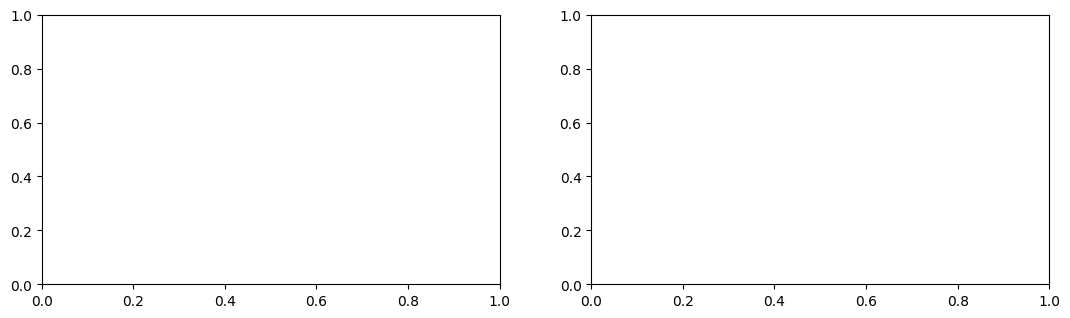

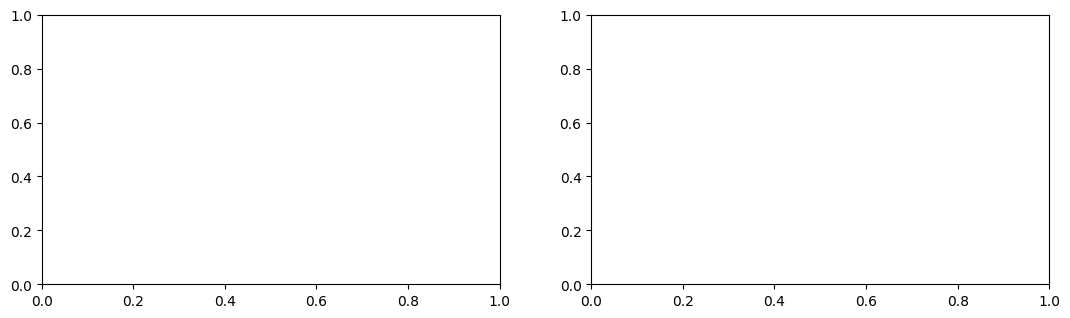

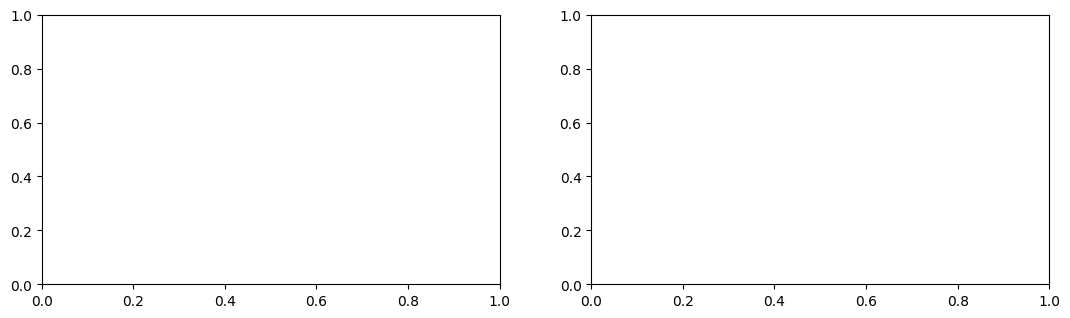

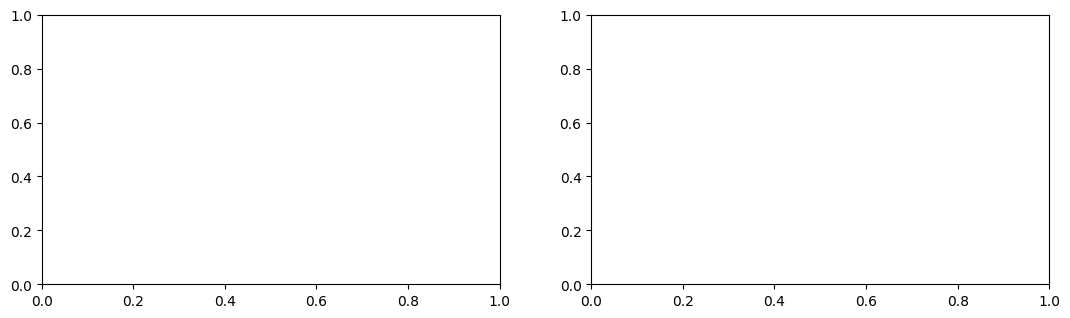

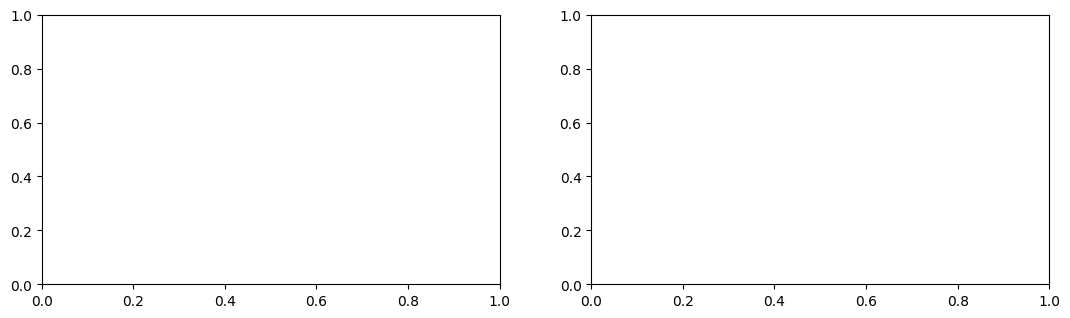

In [22]:
sw = pd.read_csv('test_files.csv').values
k = 22000
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[k:k+1], on_incidence=True,
              idx_s=0, idx_e=5, show_fig_flag=True,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='sw100k')


In [4]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.0005,
             suff_m='sw100k', suff='_inc_05')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [5]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.00075,
             suff_m='sw100k', suff='_inc_075')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [6]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.01,
             suff_m='sw100k', suff='_inc_1')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [7]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.0125,
             suff_m='sw100k', suff='_inc_125')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta


In [8]:
sw = pd.read_csv('test_files.csv').values
apply_methods(seed_dirs="../new_sw_100000/",
              seed_numbers=sw[::10], on_incidence=True,
              idx_s=0, idx_e=4, show_fig_flag=False,
             is_filename=True, sigma=0.3, gamma=0.2, 
              perc_switch=0.015,
             suff_m='sw100k', suff='_inc_15')

path:  
last value
path:  
expanding mean last value
path:  sw100k_median_beta.csv
median beta
path:  sw100k_regression_bt.joblib
regression beta
